## Environment


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from scipy.stats import wasserstein_distance, ks_2samp
from scipy import stats
from tqdm import tqdm

torch.manual_seed(42)
np.random.seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

def plot_results(images, nrow=10, title=None):
    images = (images.cpu().detach().clone() * 0.5 + 0.5).clamp(0, 1)
    grid = torchvision.utils.make_grid(images, nrow=nrow, padding=1, normalize=False)
    plt.figure(figsize=(10, (images.size(0) // nrow + 1) * 1.0), dpi=300)
    np_grid = grid.permute(1, 2, 0).numpy()
    plt.imshow(np_grid)
    plt.axis("off")
    if title is not None:
        plt.title(title, fontsize=16)
    plt.show()

Using device: cuda


## VAE Model

In [2]:
class PreActResidualBlock(nn.Module):
    """Pre-activation ResBlock: GN -> SiLU -> Conv -> GN -> SiLU -> Conv + shortcut."""
    def __init__(self, in_channels, out_channels, groups=8, dropout=0.1):
        super().__init__()
        self.gn1 = nn.GroupNorm(groups, in_channels)
        self.act1 = nn.SiLU()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False)

        self.gn2 = nn.GroupNorm(groups, out_channels)
        self.act2 = nn.SiLU()
        self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)

        self.shortcut = (
            nn.Conv2d(in_channels, out_channels, 1, bias=False)
            if in_channels != out_channels else nn.Identity()
        )

    def forward(self, x):
        out = self.conv1(self.act1(self.gn1(x)))
        out = self.conv2(self.dropout(self.act2(self.gn2(out))))
        return out + self.shortcut(x)


class ConvVAE(nn.Module):
    def __init__(self, latent_dim=128, img_channels=1, groups=8, dropout=0.1,
                 out_activation="tanh"):  # out_activation: "tanh" or "sigmoid"
        super().__init__()
        self.latent_dim = latent_dim
        self.img_channels = img_channels
        self.out_activation = out_activation

        # ----------------
        # Encoder: 28 -> 14 -> 7 -> 4
        # ----------------
        self.enc = nn.Sequential(
            # 28 -> 14
            nn.Conv2d(img_channels, 32, 3, stride=2, padding=1, bias=False),
            PreActResidualBlock(32, 32, groups=groups, dropout=dropout),

            # 14 -> 7
            nn.Conv2d(32, 64, 3, stride=2, padding=1, bias=False),
            PreActResidualBlock(64, 64, groups=groups, dropout=dropout),

            # 7 -> 4
            nn.Conv2d(64, 128, 3, stride=2, padding=1, bias=False),
            PreActResidualBlock(128, 128, groups=groups, dropout=dropout),
        )
        self.mid = PreActResidualBlock(128, 128, groups=groups, dropout=dropout)

        self.flatten_dim = 128 * 4 * 4
        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

        # ----------------
        # Decoder: z -> 4x4 -> 7 -> 14 -> 28
        # ----------------
        self.fc_decode = nn.Linear(latent_dim, self.flatten_dim)

        self.dec1 = nn.Sequential(
            # 4 -> 7  (k=3,s=2,p=1 gives 7)
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=0, bias=False),
            nn.GroupNorm(groups, 64),
            nn.SiLU(),
            PreActResidualBlock(64, 64, groups=groups, dropout=dropout),
        )
        self.dec2 = nn.Sequential(
            # 7 -> 14
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1, bias=False),
            nn.GroupNorm(groups, 32),
            nn.SiLU(),
            PreActResidualBlock(32, 32, groups=groups, dropout=dropout),
        )
        self.dec3 = nn.Sequential(
            # 14 -> 28
            nn.ConvTranspose2d(32, 32, 4, stride=2, padding=1, bias=False),
            nn.GroupNorm(groups, 32),
            nn.SiLU(),
        )
        self.out_conv = nn.Conv2d(32, img_channels, 3, padding=1)

        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(m):
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            if getattr(m, 'bias', None) is not None:
                nn.init.zeros_(m.bias)
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def encode(self, x):
        h = self.enc(x)
        h = self.mid(h)
        h = h.view(h.size(0), -1)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(h.size(0), 128, 4, 4)
        h = self.dec1(h)
        h = self.dec2(h)
        h = self.dec3(h)
        h = self.out_conv(h)
        if self.out_activation == "sigmoid":
            return torch.sigmoid(h)
        else:
            return torch.tanh(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar


## Loss Function & Training Script

In [3]:
def vae_loss_function(recon_x, x, mu, logvar, beta=1.0):
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kld, recon_loss, kld


def train_conv_vae(vae, train_loader, epochs=20, device='cuda', beta=1.0, lr=1e-3):
    vae = vae.to(device)
    optimizer = torch.optim.AdamW(vae.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    print("Training Convolutional VAE...")
    print(f"Model parameters: {sum(p.numel() for p in vae.parameters()):,}")

    history = {"loss": [], "recon": [], "kld": []}

    for epoch in range(epochs):
        vae.train()
        train_loss = 0
        train_recon = 0
        train_kld = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for batch_idx, (data, _) in enumerate(pbar):
            data = data.to(device)
            optimizer.zero_grad()

            recon_batch, mu, logvar = vae(data)
            loss, recon_loss, kld = vae_loss_function(recon_batch, data, mu, logvar, beta)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(vae.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item()
            train_recon += recon_loss.item()
            train_kld += kld.item()

            pbar.set_postfix({
                'loss': f'{loss.item()/len(data):.2f}',
                'recon': f'{recon_loss.item()/len(data):.2f}',
                'kld': f'{kld.item()/len(data):.2f}'
            })

        n_samples = len(train_loader.dataset)
        avg_loss = train_loss / n_samples
        avg_recon = train_recon / n_samples
        avg_kld = train_kld / n_samples

        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        history['loss'].append(avg_loss)
        history['recon'].append(avg_recon)
        history['kld'].append(avg_kld)

        print(f'Epoch {epoch+1}/{epochs}:')
        print(f'  Total Loss: {avg_loss:.4f}')
        print(f'  Recon Loss: {avg_recon:.4f}')
        print(f'  KLD Loss:   {avg_kld:.4f}')
        print(f'  LR:         {current_lr:.6f}')

    return vae, history

## Load MNIST Dataset

In [4]:
print("="*60)
print("STEP 1: Loading MNIST Dataset")
print("="*60)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,
                          num_workers=4, pin_memory=True)

print(f"Dataset loaded: {len(train_dataset)} training images")

STEP 1: Loading MNIST Dataset


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.34MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.21MB/s]

Dataset loaded: 60000 training images



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


## Train and Save the Model

In [7]:
print("\n" + "="*60)
print("STEP 2: Training Convolutional VAE")
print("="*60)

latent_dim = 128
vae = ConvVAE(latent_dim=latent_dim, img_channels=1)
beta = 3
vae, history = train_conv_vae(vae, train_loader, epochs=40, device=device, beta=beta, lr=1e-3)

torch.save({
    'model_state_dict': vae.state_dict(),
    'latent_dim': latent_dim,
    'history': history,
}, f'conv_vae_checkpoint_{beta}.pt')
print("\n ✓ VAE checkpoint saved!")


STEP 2: Training Convolutional VAE
Training Convolutional VAE...
Model parameters: 1,780,545


Epoch 1/40: 100%|██████████| 469/469 [00:19<00:00, 24.02it/s, loss=140.09, recon=92.65, kld=15.81]


Epoch 1/40:
  Total Loss: 1236.7399
  Recon Loss: 126.2827
  KLD Loss:   370.1524
  LR:         0.000998


Epoch 2/40: 100%|██████████| 469/469 [00:18<00:00, 25.54it/s, loss=119.22, recon=77.34, kld=13.96]


Epoch 2/40:
  Total Loss: 122.1841
  Recon Loss: 77.8739
  KLD Loss:   14.7700
  LR:         0.000994


...

Epoch 38/40:
  Total Loss: 90.2552
  Recon Loss: 44.6624
  KLD Loss:   15.1976
  LR:         0.000006


Epoch 39/40: 100%|██████████| 469/469 [00:19<00:00, 23.96it/s, loss=90.50, recon=44.24, kld=15.42]


Epoch 39/40:
  Total Loss: 90.1127
  Recon Loss: 44.5159
  KLD Loss:   15.1989
  LR:         0.000002


Epoch 40/40: 100%|██████████| 469/469 [00:18<00:00, 25.32it/s, loss=91.18, recon=44.67, kld=15.50]


Epoch 40/40:
  Total Loss: 90.1548
  Recon Loss: 44.6085
  KLD Loss:   15.1821
  LR:         0.000000

 ✓ VAE checkpoint saved!


## Visualize Reconstruction

Visualizing VAE Reconstruction


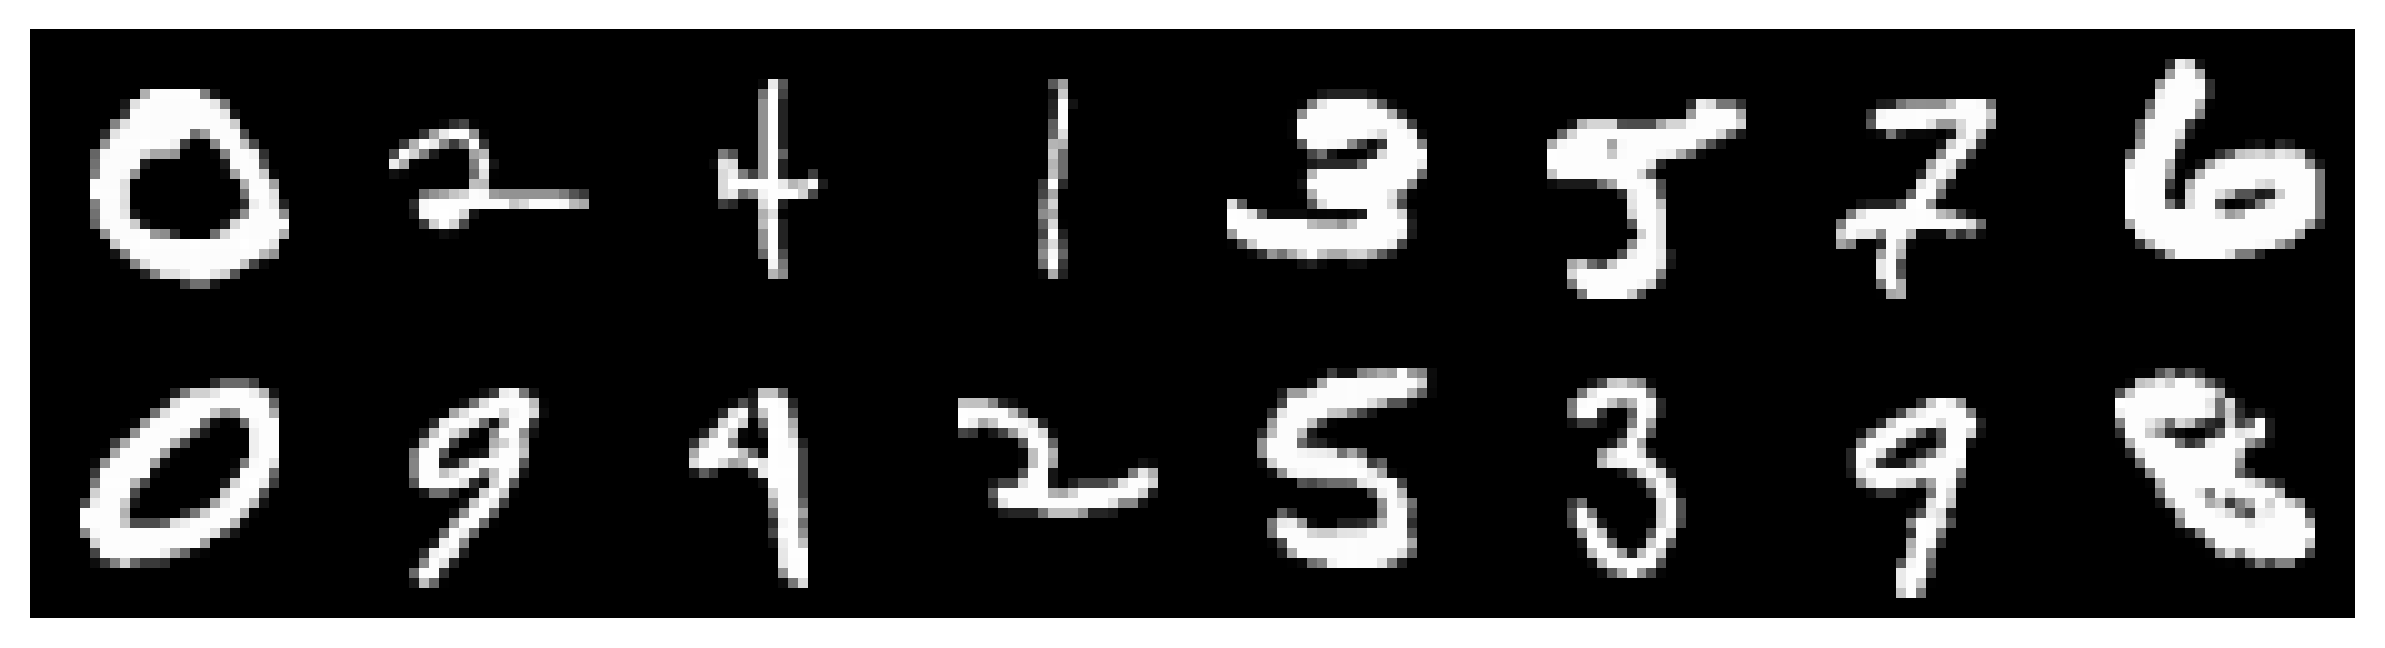

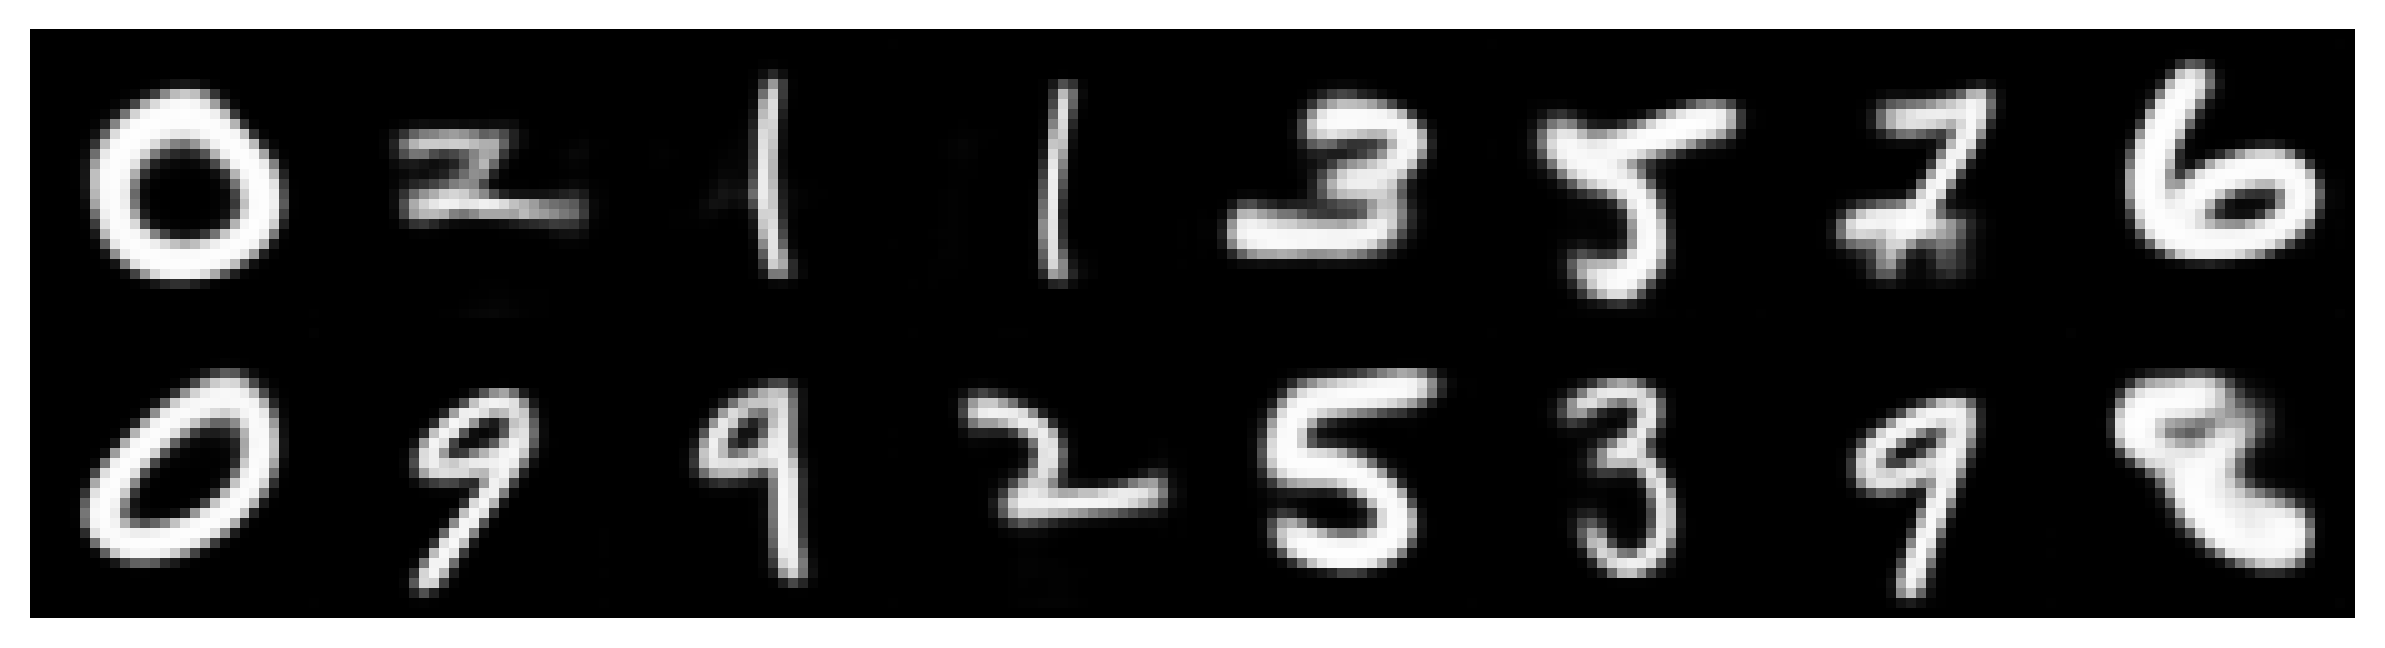

In [8]:
print("="*60)
print("Visualizing VAE Reconstruction")
print("="*60)

vae.eval()
with torch.no_grad():
    test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=True)

    data, _ = next(iter(test_loader))
    data = data.to(device)

    recon, mu, logvar = vae(data)

    plot_results(data, nrow=8)
    plot_results(recon, nrow=8)

## Visualize Generation

Visualizing Random Generation from Latent Space


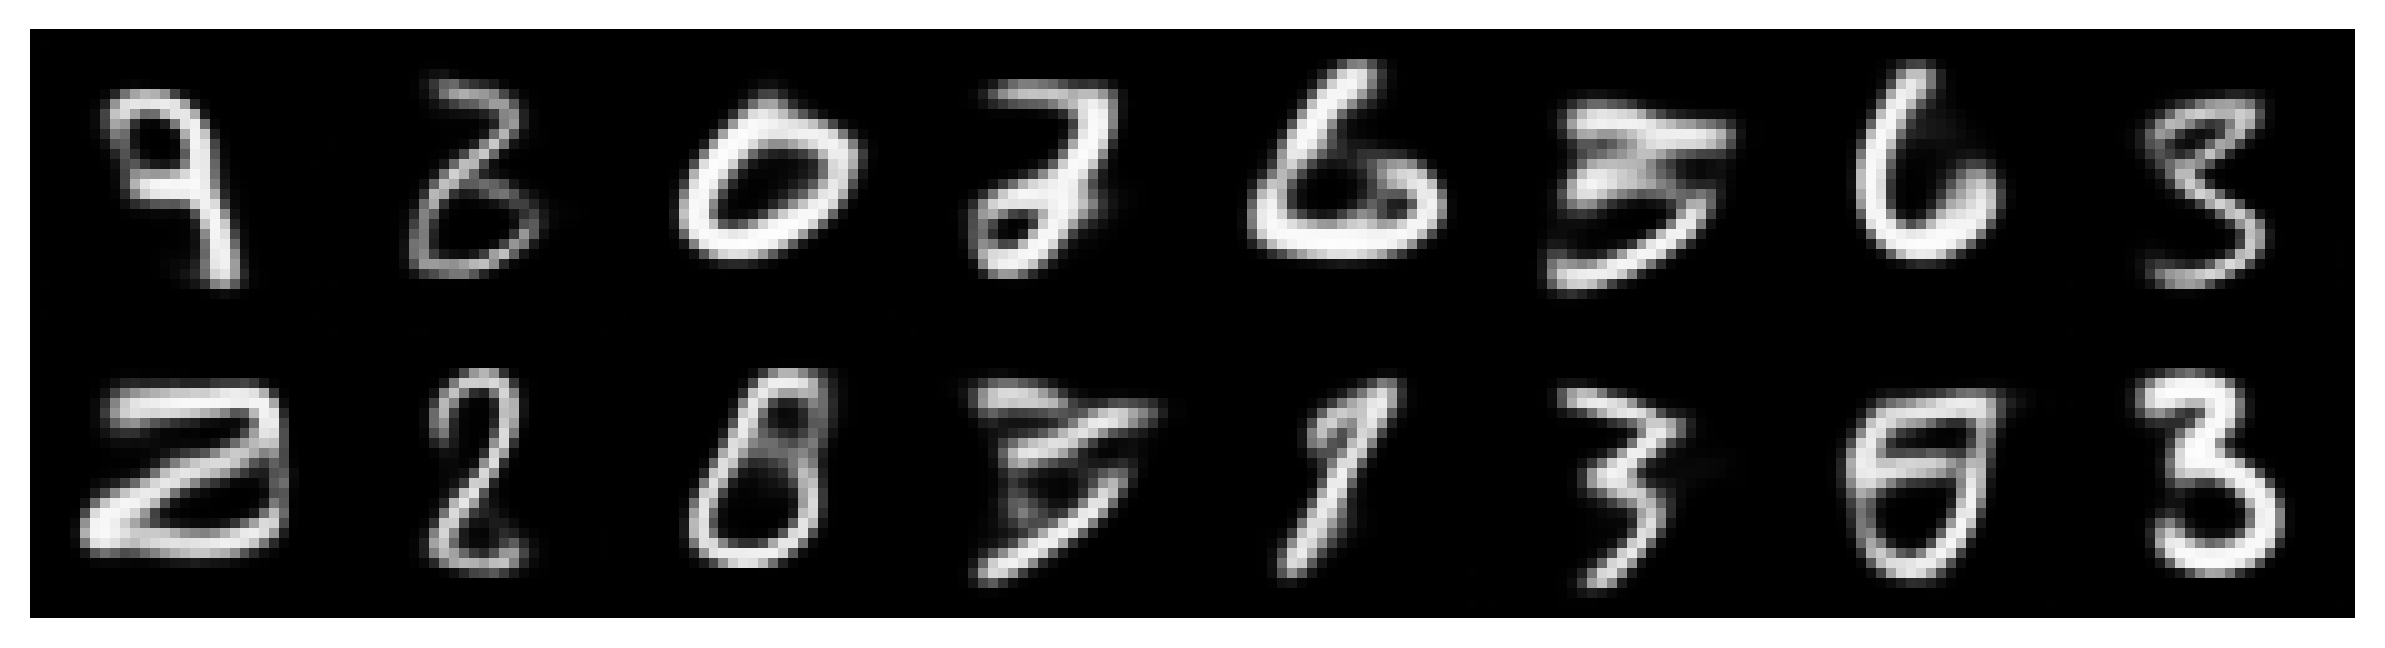

In [9]:
print("="*60)
print("Visualizing Random Generation from Latent Space")
print("="*60)

vae.eval()
with torch.no_grad():
    n_samples = 16
    z = torch.randn(n_samples, latent_dim).to(device)

    generated = vae.decode(z)
    generated_np = generated.cpu().numpy()

    plot_results(generated, nrow=8)

## β-VAE Experiments


β-VAE Experiment (β=0.5)
Training Convolutional VAE...
Model parameters: 1,780,545


Epoch 1/40: 100%|██████████| 469/469 [00:19<00:00, 24.54it/s, loss=59.72, recon=34.22, kld=51.00]


Epoch 1/40:
  Total Loss: 196.1081
  Recon Loss: 66.4895
  KLD Loss:   259.2372
  LR:         0.000998


Epoch 2/40: 100%|██████████| 469/469 [00:17<00:00, 26.26it/s, loss=50.23, recon=26.88, kld=46.71]


Epoch 2/40:
  Total Loss: 56.0951
  Recon Loss: 31.6140
  KLD Loss:   48.9621
  LR:         0.000994


...

Epoch 38/40:
  Total Loss: 37.3780
  Recon Loss: 16.5881
  KLD Loss:   41.5797
  LR:         0.000006


Epoch 39/40: 100%|██████████| 469/469 [00:18<00:00, 24.96it/s, loss=38.58, recon=17.53, kld=42.11]


Epoch 39/40:
  Total Loss: 37.3377
  Recon Loss: 16.5555
  KLD Loss:   41.5643
  LR:         0.000002


Epoch 40/40: 100%|██████████| 469/469 [00:19<00:00, 23.87it/s, loss=37.10, recon=16.02, kld=42.16]


Epoch 40/40:
  Total Loss: 37.3276
  Recon Loss: 16.5292
  KLD Loss:   41.5967
  LR:         0.000000
Final Reconstruction Loss: 16.5292
Final KL Divergence:      41.5967
Recon/KL Ratio:           0.40


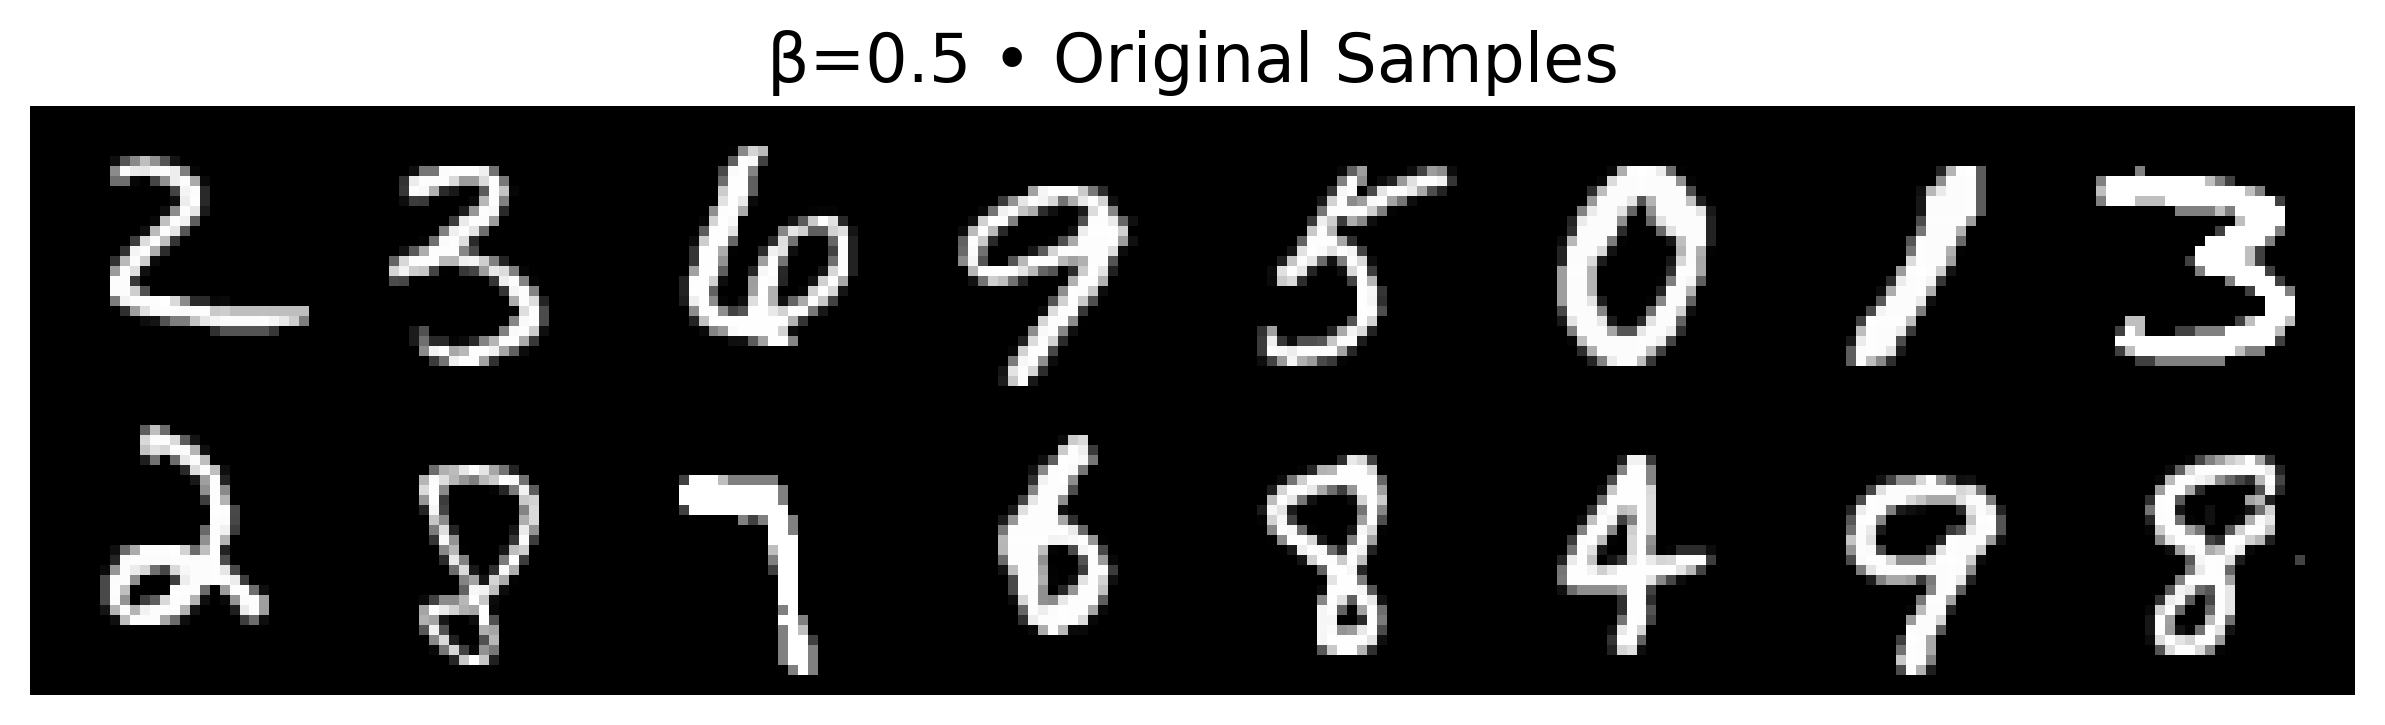

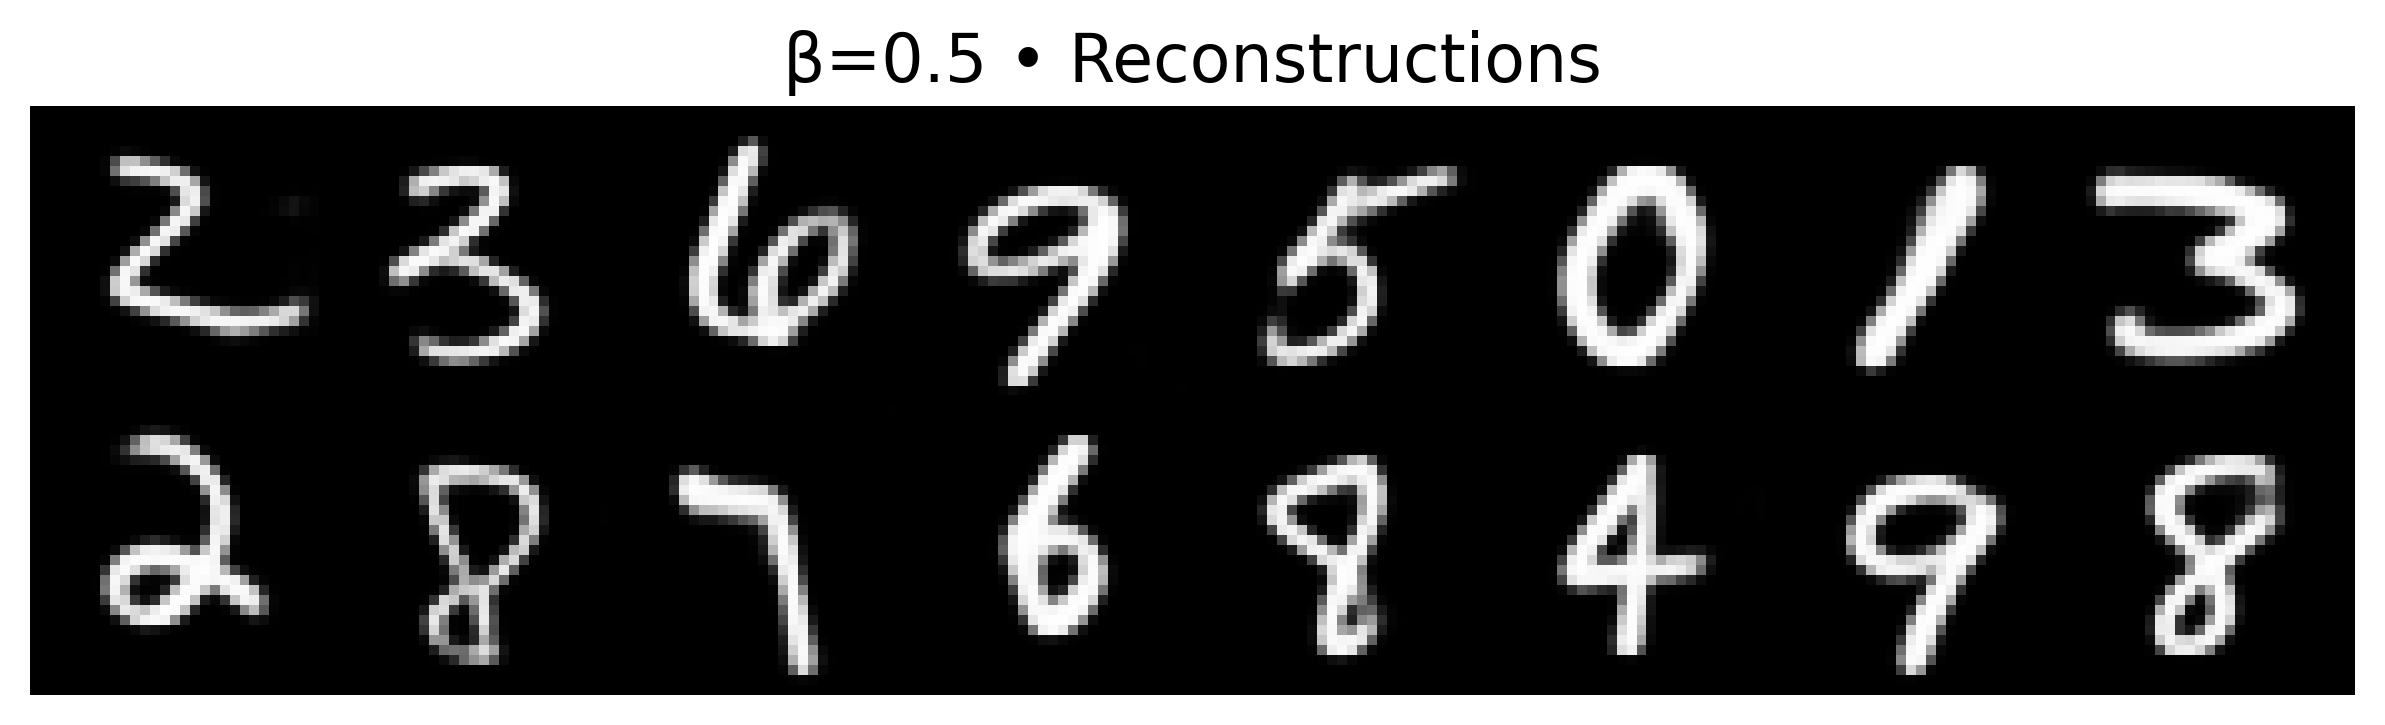

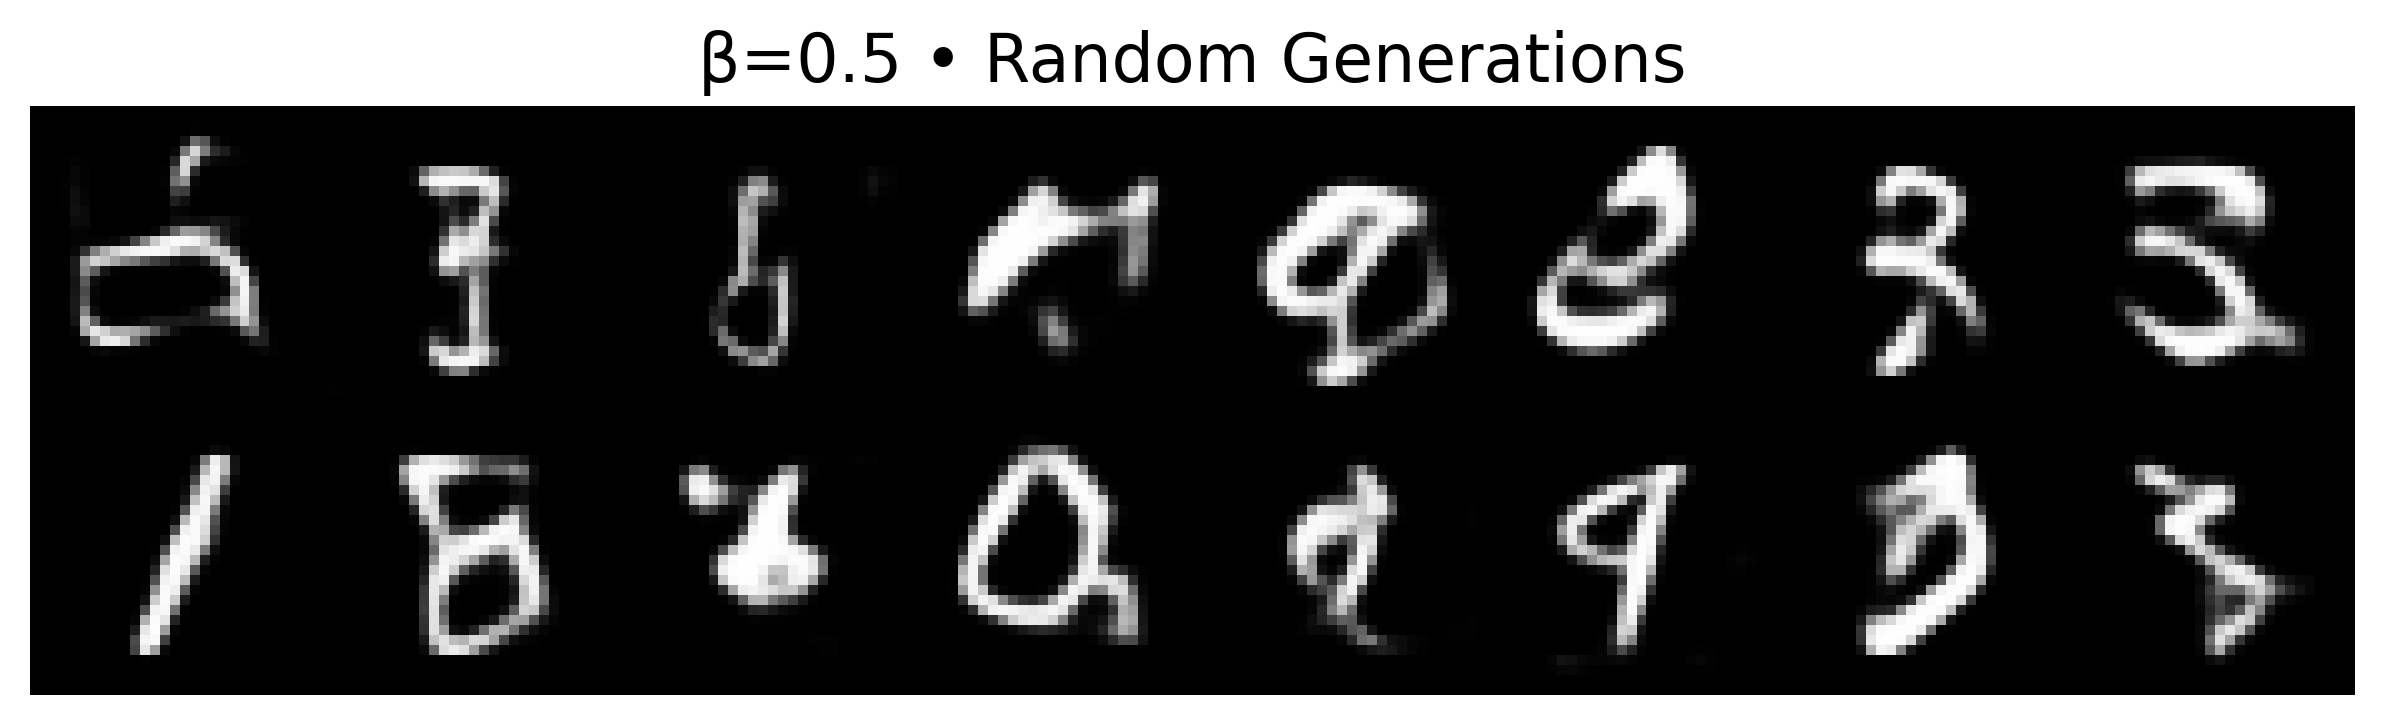

β-VAE Experiment (β=1.0)
Training Convolutional VAE...
Model parameters: 1,780,545


Epoch 1/40: 100%|██████████| 469/469 [00:19<00:00, 24.26it/s, loss=83.27, recon=50.83, kld=32.44]


Epoch 1/40:
  Total Loss: 182.7860
  Recon Loss: 83.3808
  KLD Loss:   99.4052
  LR:         0.000998


Epoch 2/40: 100%|██████████| 469/469 [00:20<00:00, 22.76it/s, loss=70.17, recon=37.82, kld=32.35]


Epoch 2/40:
  Total Loss: 75.6954
  Recon Loss: 43.4093
  KLD Loss:   32.2861
  LR:         0.000994


...

Epoch 38/40:
  Total Loss: 53.3768
  Recon Loss: 24.5457
  KLD Loss:   28.8311
  LR:         0.000006


Epoch 39/40: 100%|██████████| 469/469 [00:18<00:00, 24.71it/s, loss=52.81, recon=23.98, kld=28.83]


Epoch 39/40:
  Total Loss: 53.3178
  Recon Loss: 24.5037
  KLD Loss:   28.8141
  LR:         0.000002


Epoch 40/40: 100%|██████████| 469/469 [00:19<00:00, 23.51it/s, loss=52.28, recon=23.74, kld=28.55]


Epoch 40/40:
  Total Loss: 53.2964
  Recon Loss: 24.4601
  KLD Loss:   28.8363
  LR:         0.000000
Final Reconstruction Loss: 24.4601
Final KL Divergence:      28.8363
Recon/KL Ratio:           0.85


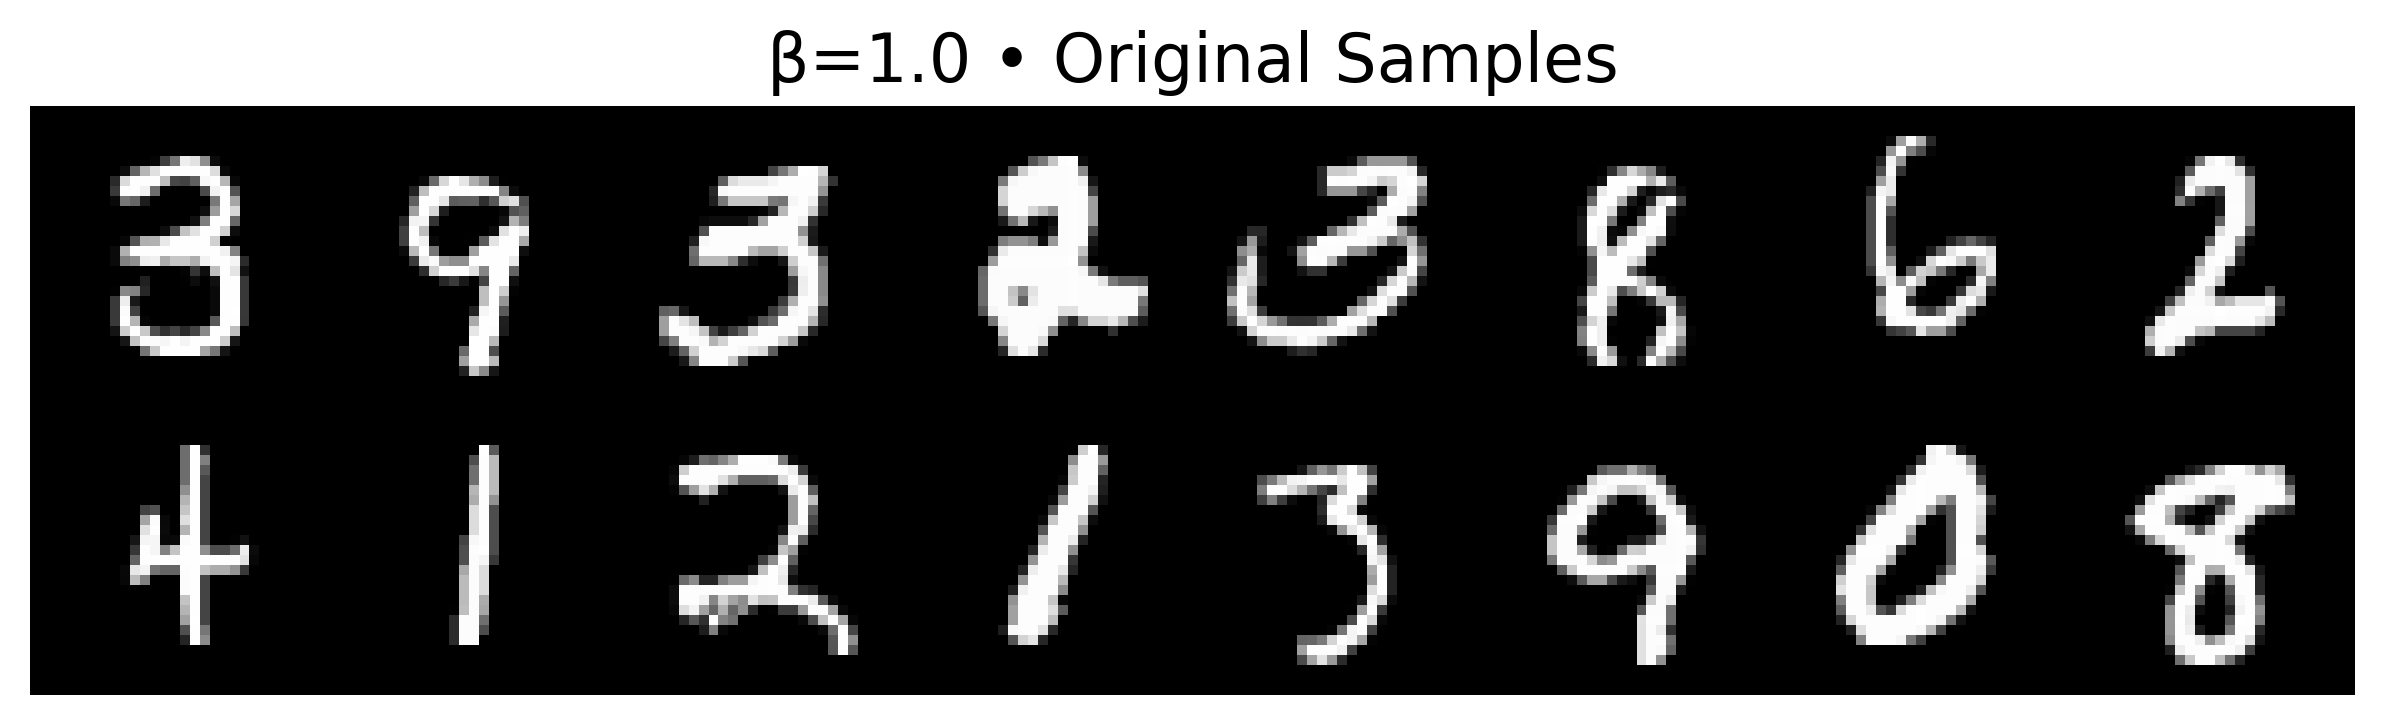

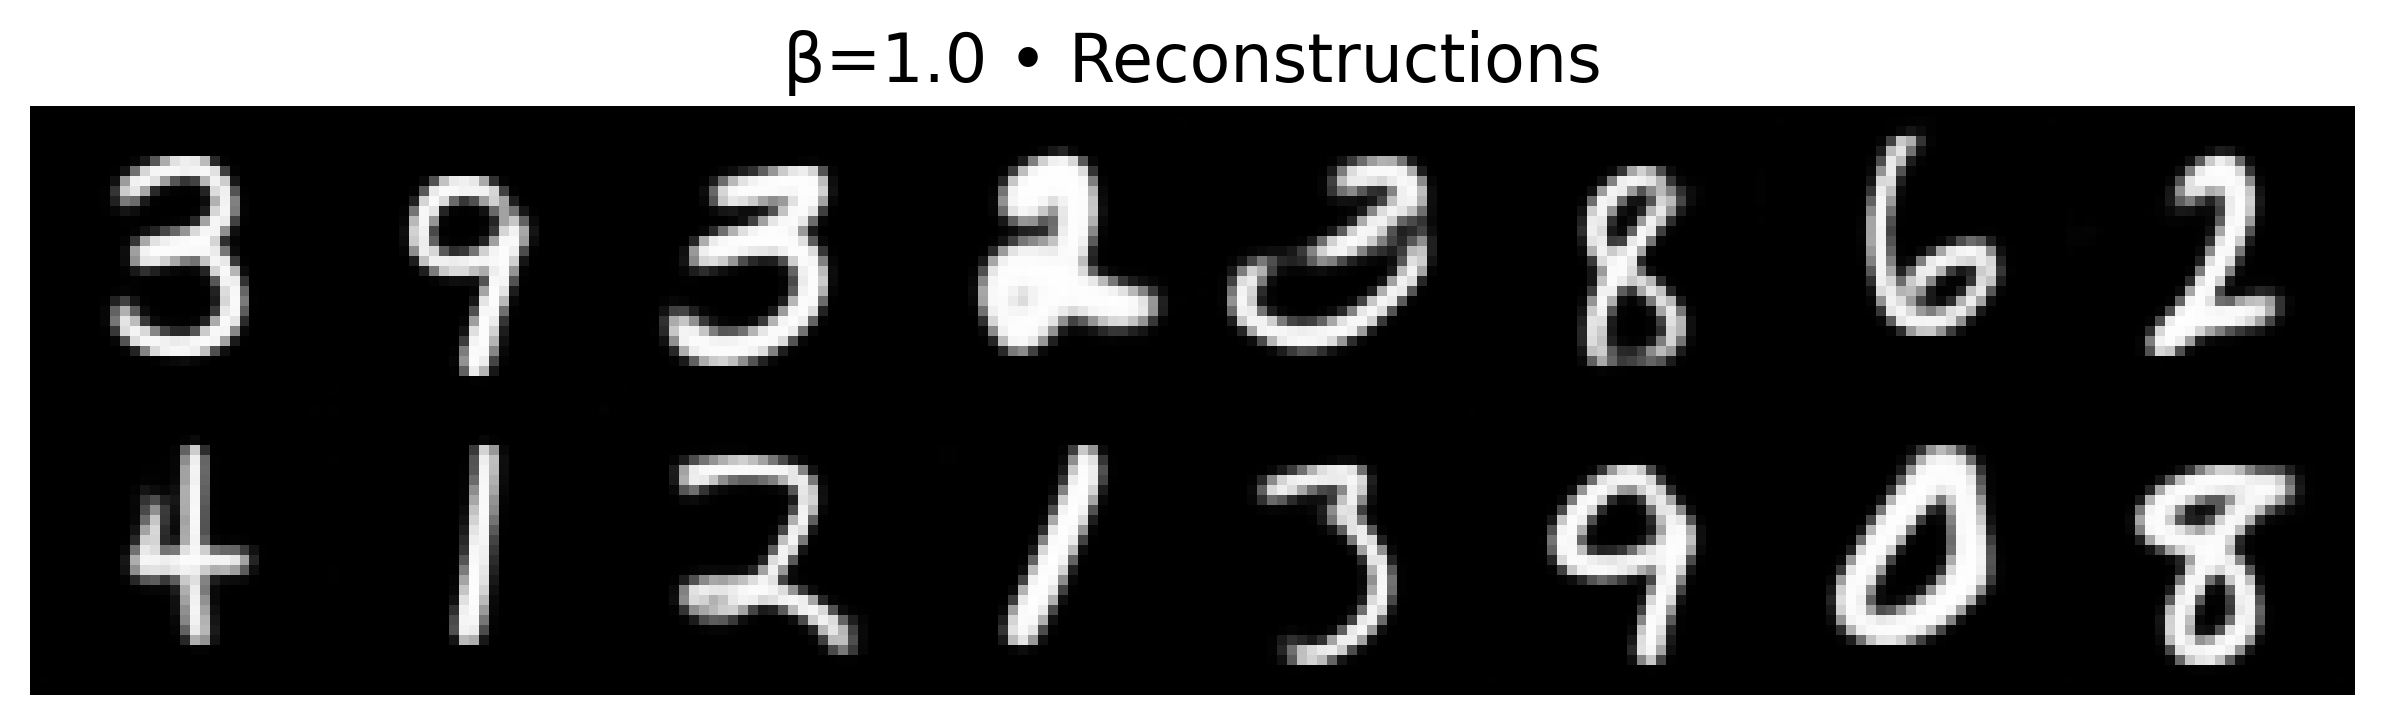

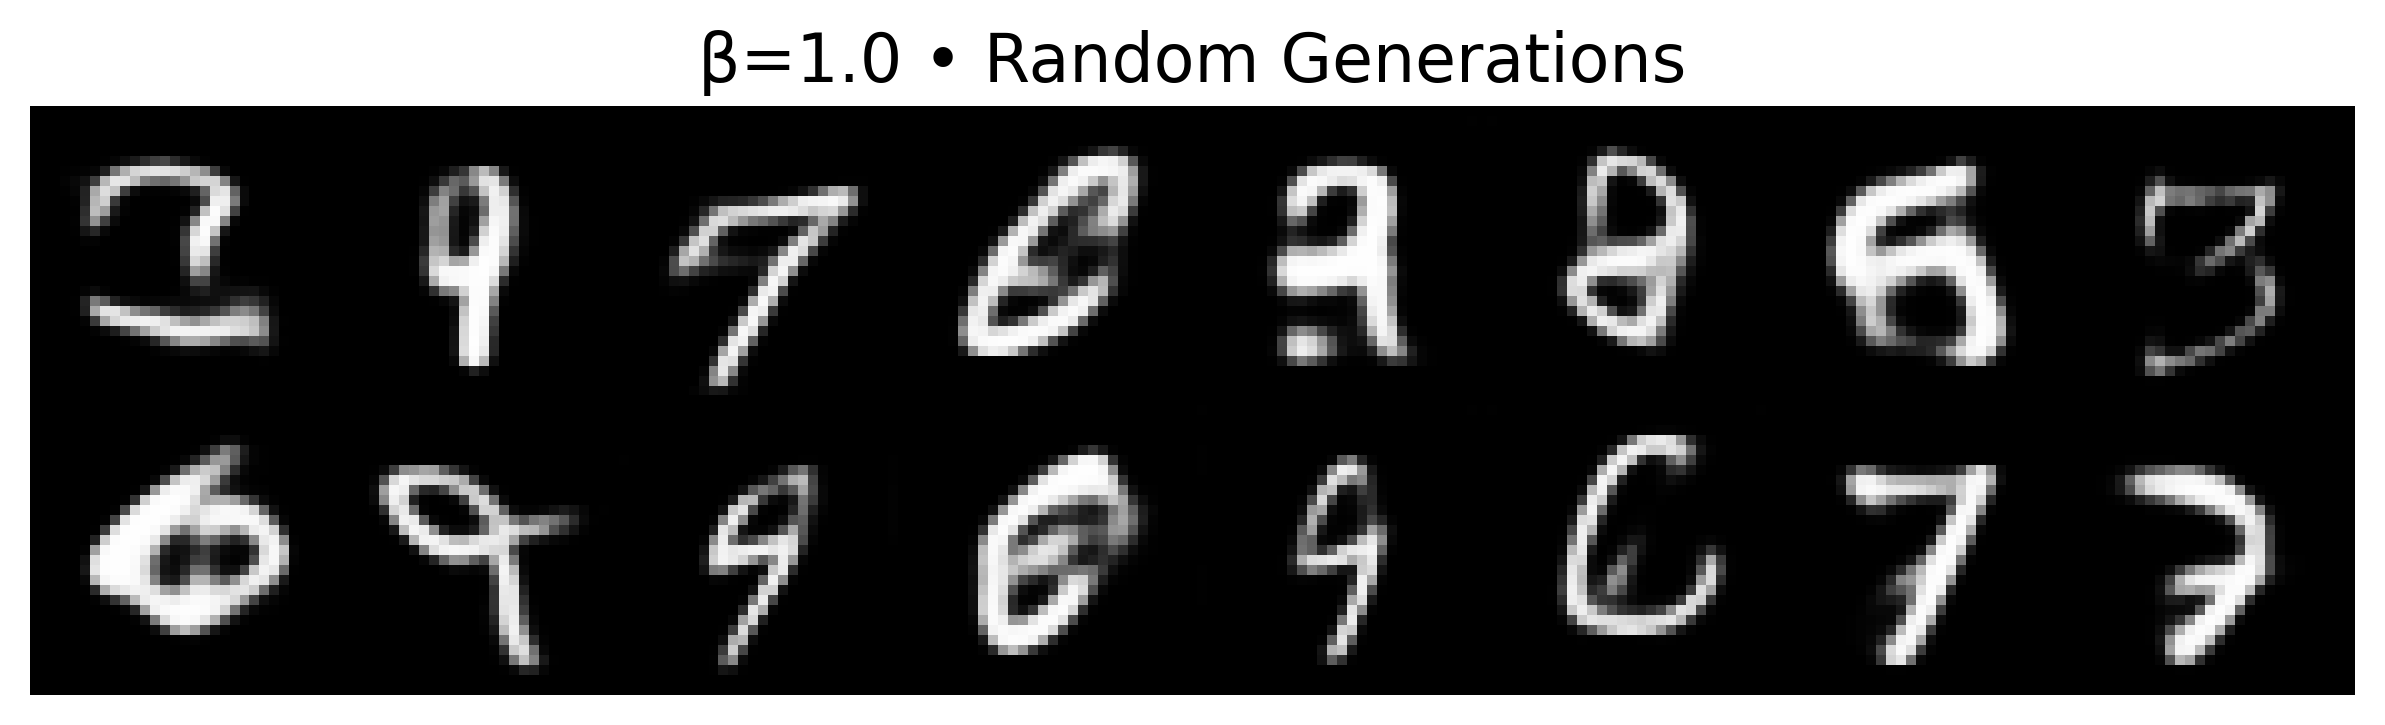

β-VAE Experiment (β=3.0)
Training Convolutional VAE...
Model parameters: 1,780,545


Epoch 1/40: 100%|██████████| 469/469 [00:19<00:00, 23.52it/s, loss=128.60, recon=83.14, kld=15.15]


Epoch 1/40:
  Total Loss: 482.0111
  Recon Loss: 121.2041
  KLD Loss:   120.2690
  LR:         0.000998


Epoch 2/40: 100%|██████████| 469/469 [00:20<00:00, 22.41it/s, loss=117.81, recon=68.97, kld=16.28]


Epoch 2/40:
  Total Loss: 121.6481
  Recon Loss: 77.1755
  KLD Loss:   14.8242
  LR:         0.000994


...

Epoch 38/40:
  Total Loss: 90.2449
  Recon Loss: 44.8420
  KLD Loss:   15.1343
  LR:         0.000006


Epoch 39/40: 100%|██████████| 469/469 [00:19<00:00, 23.75it/s, loss=89.70, recon=45.41, kld=14.76]


Epoch 39/40:
  Total Loss: 90.1992
  Recon Loss: 44.7549
  KLD Loss:   15.1481
  LR:         0.000002


Epoch 40/40: 100%|██████████| 469/469 [00:20<00:00, 23.14it/s, loss=89.55, recon=44.83, kld=14.91]


Epoch 40/40:
  Total Loss: 90.2523
  Recon Loss: 44.7836
  KLD Loss:   15.1563
  LR:         0.000000
Final Reconstruction Loss: 44.7836
Final KL Divergence:      15.1563
Recon/KL Ratio:           2.95


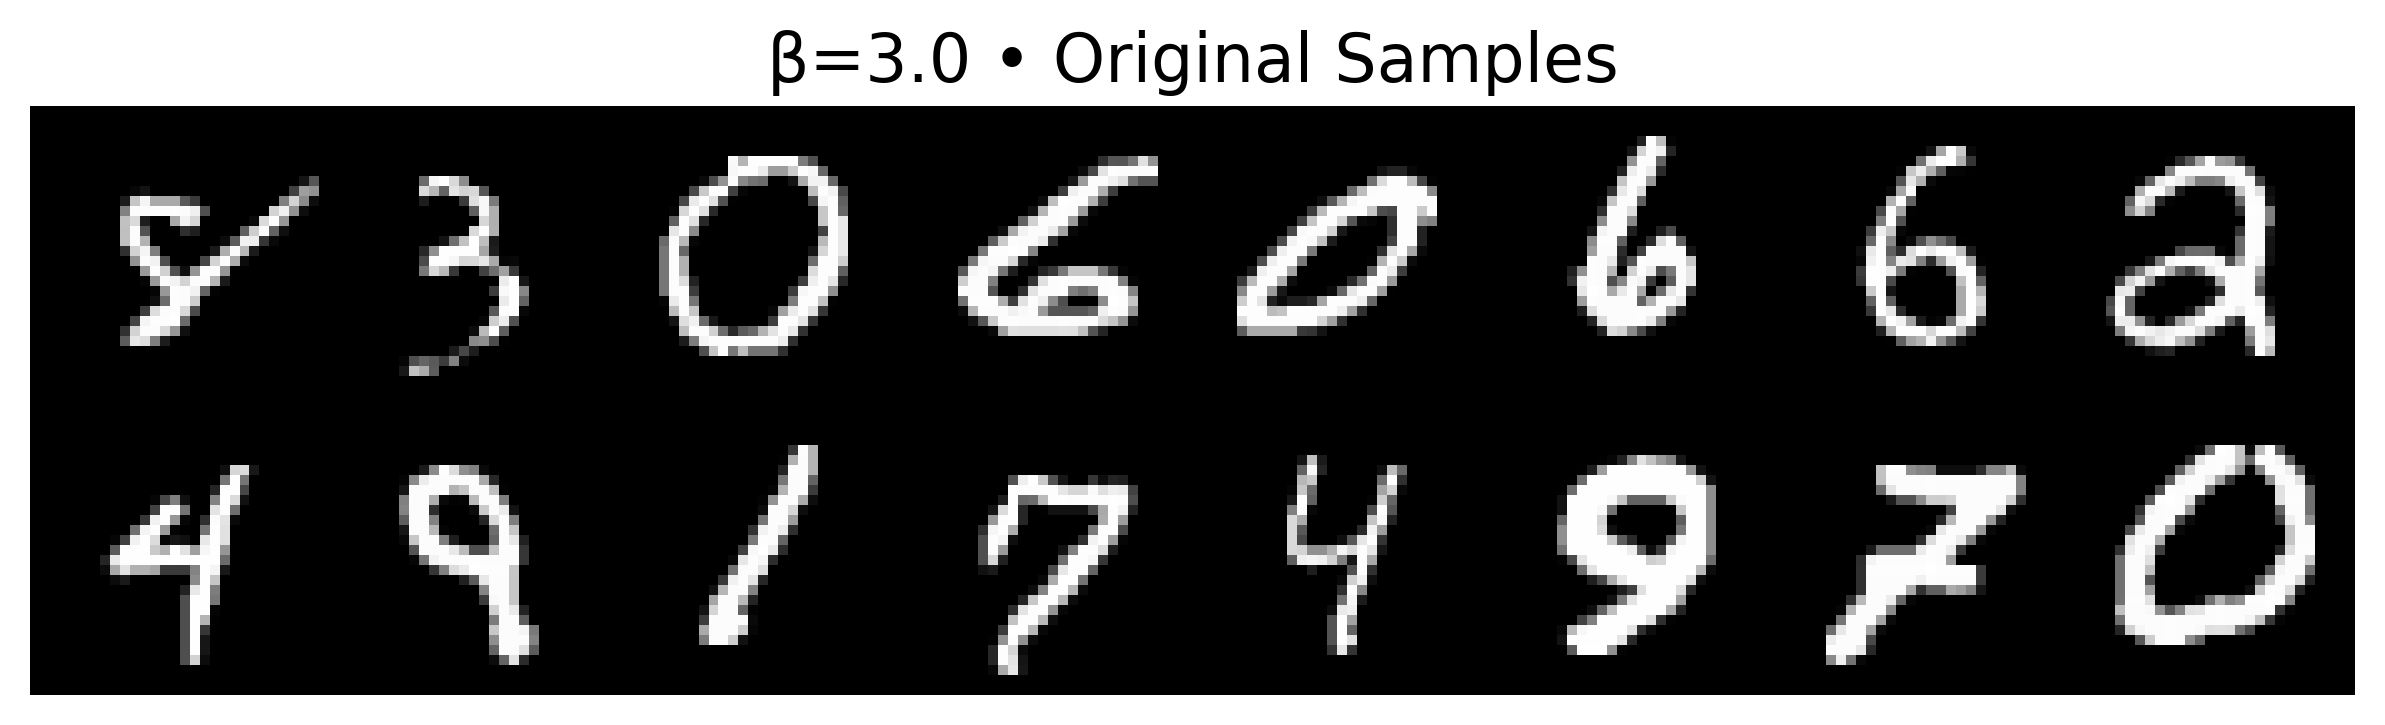

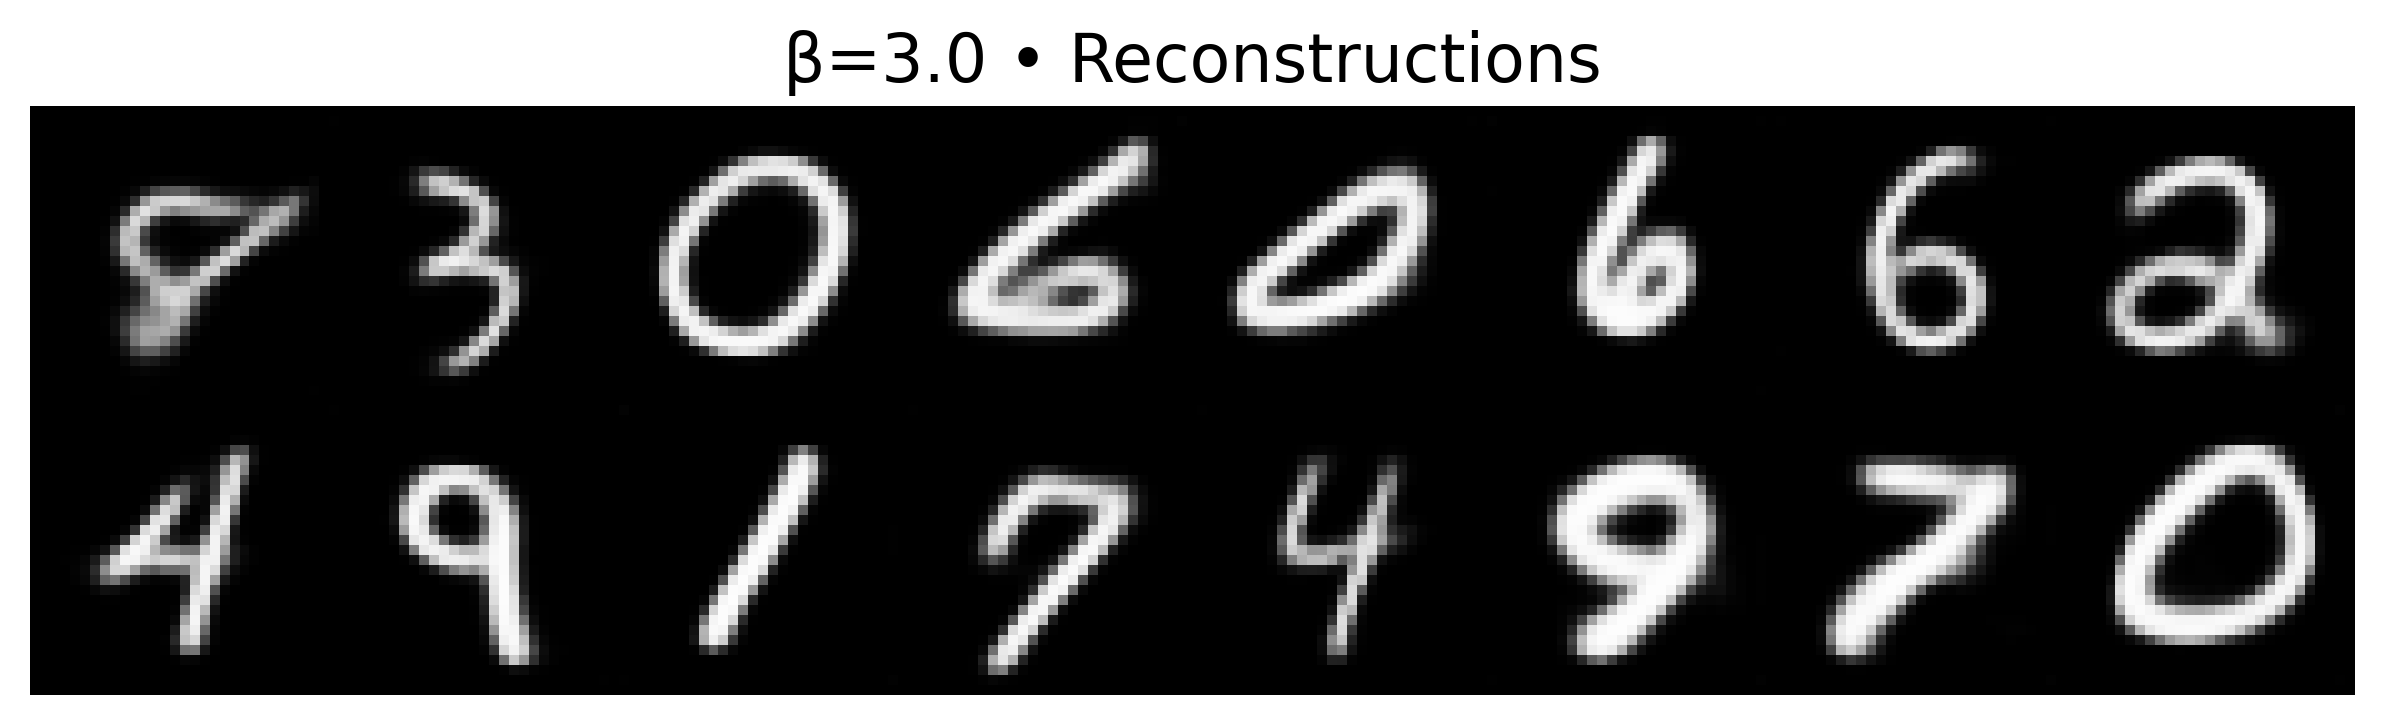

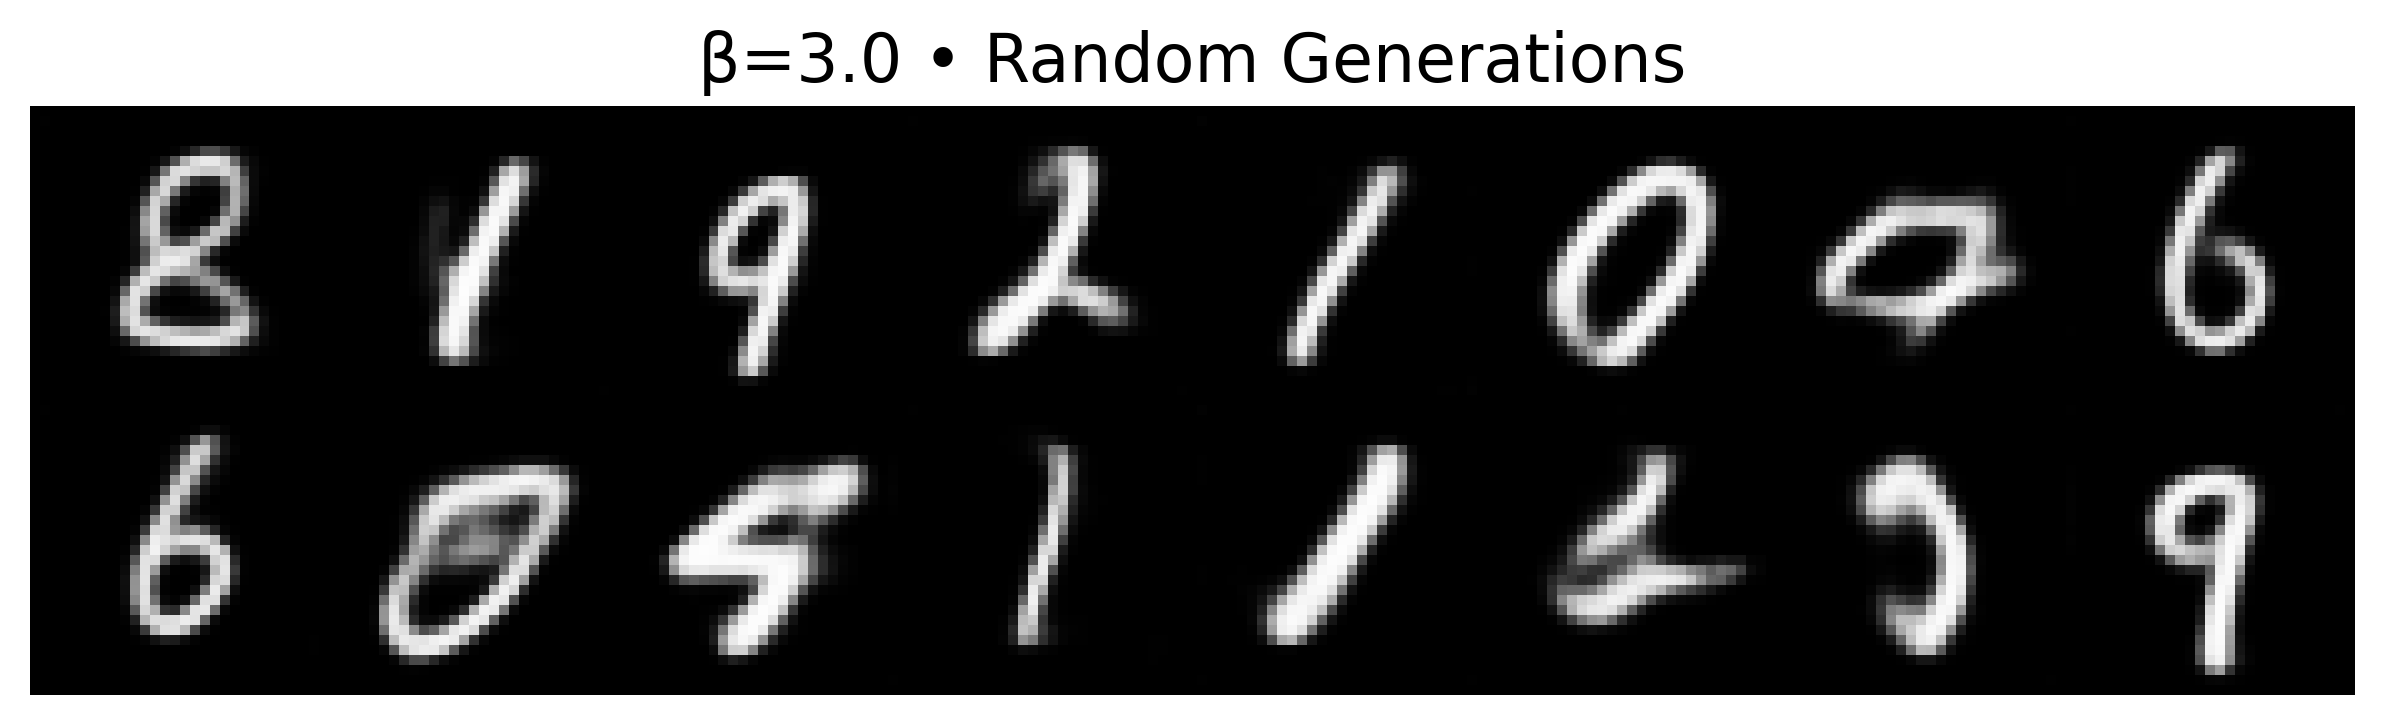

β-VAE Experiment (β=5.0)
Training Convolutional VAE...
Model parameters: 1,780,545


Epoch 1/40: 100%|██████████| 469/469 [00:20<00:00, 23.06it/s, loss=161.13, recon=117.51, kld=8.72]


Epoch 1/40:
  Total Loss: 1116.0322
  Recon Loss: 148.2675
  KLD Loss:   193.5529
  LR:         0.000998


Epoch 2/40: 100%|██████████| 469/469 [00:21<00:00, 21.93it/s, loss=148.55, recon=98.40, kld=10.03]


Epoch 2/40:
  Total Loss: 149.3252
  Recon Loss: 103.0105
  KLD Loss:   9.2629
  LR:         0.000994


...

Epoch 38/40:
  Total Loss: 115.5363
  Recon Loss: 61.0420
  KLD Loss:   10.8989
  LR:         0.000006


Epoch 39/40: 100%|██████████| 469/469 [00:22<00:00, 20.88it/s, loss=116.07, recon=61.58, kld=10.90]


Epoch 39/40:
  Total Loss: 115.3587
  Recon Loss: 60.8814
  KLD Loss:   10.8954
  LR:         0.000002


Epoch 40/40: 100%|██████████| 469/469 [00:21<00:00, 21.73it/s, loss=111.78, recon=56.76, kld=11.00]


Epoch 40/40:
  Total Loss: 115.4149
  Recon Loss: 60.8821
  KLD Loss:   10.9066
  LR:         0.000000
Final Reconstruction Loss: 60.8821
Final KL Divergence:      10.9066
Recon/KL Ratio:           5.58


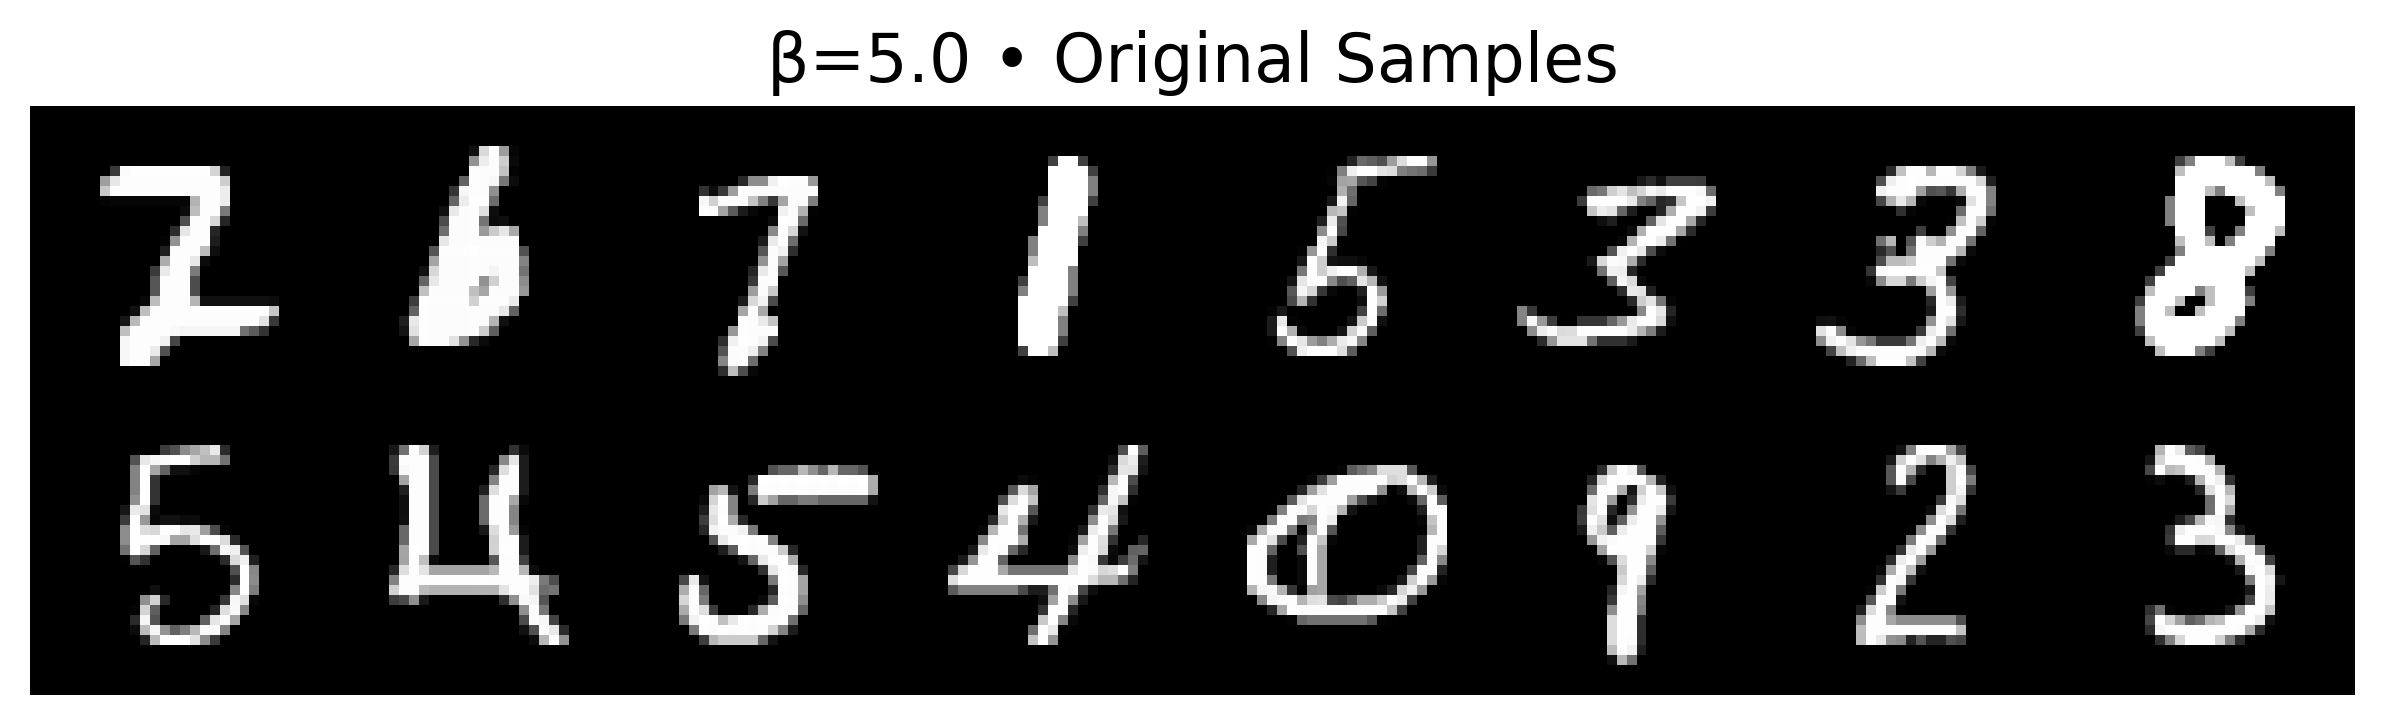

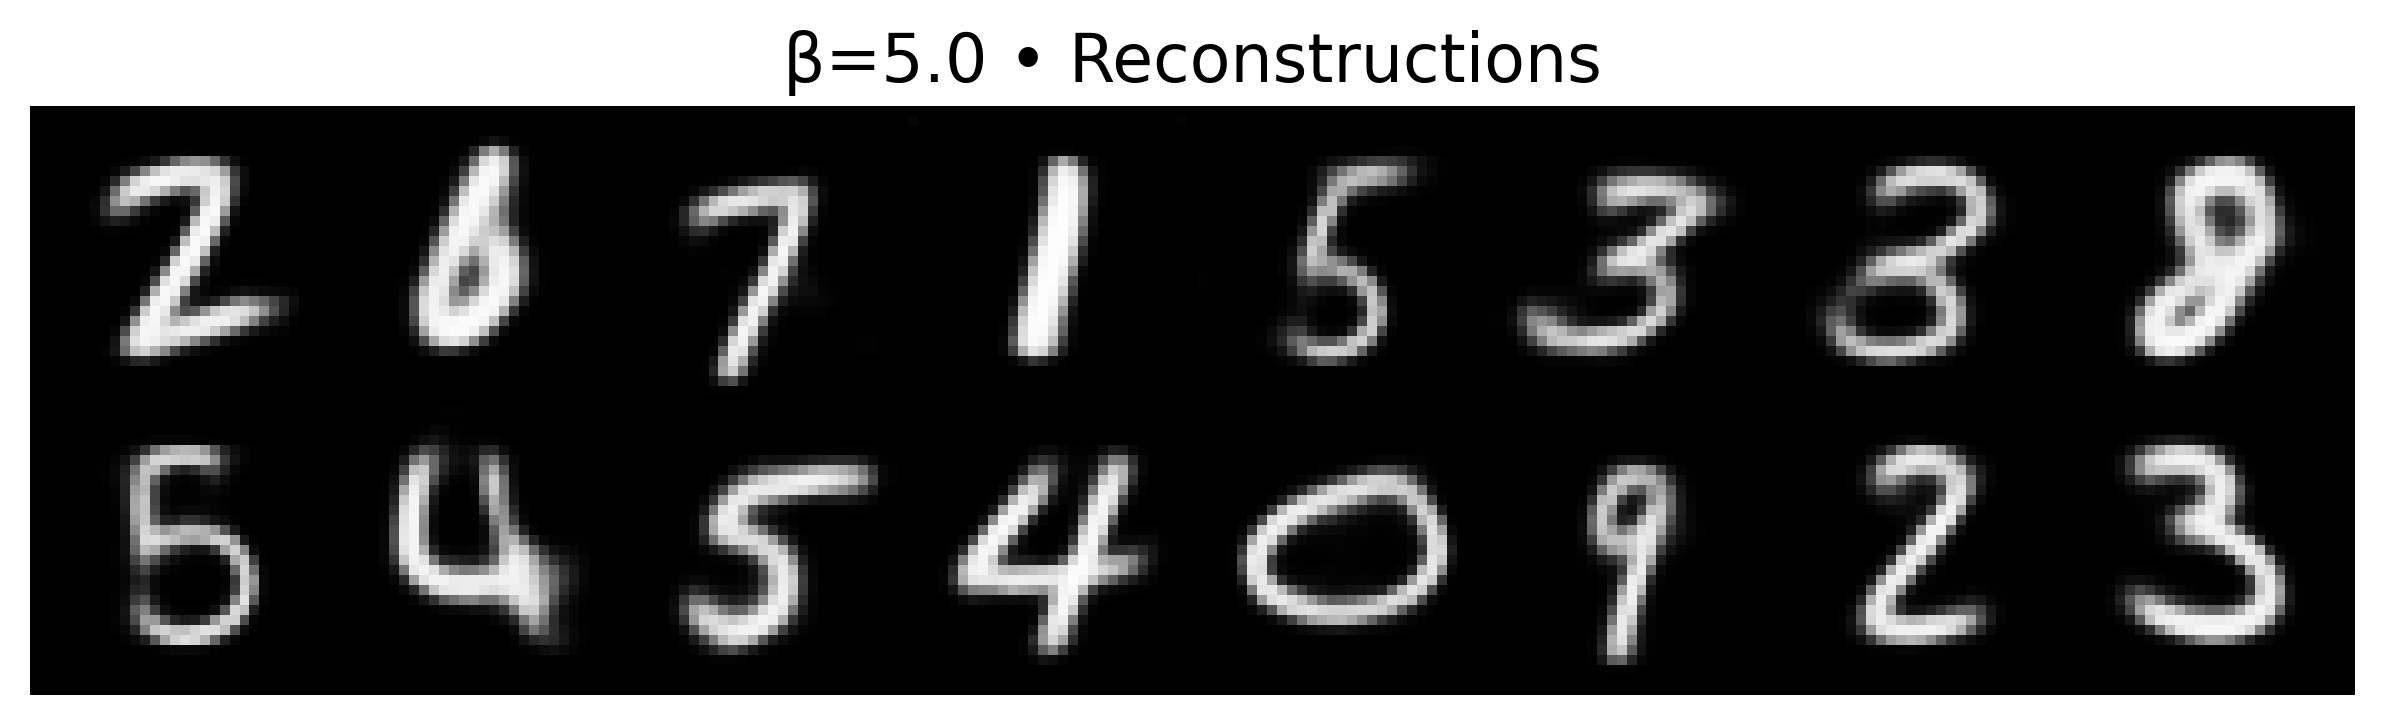

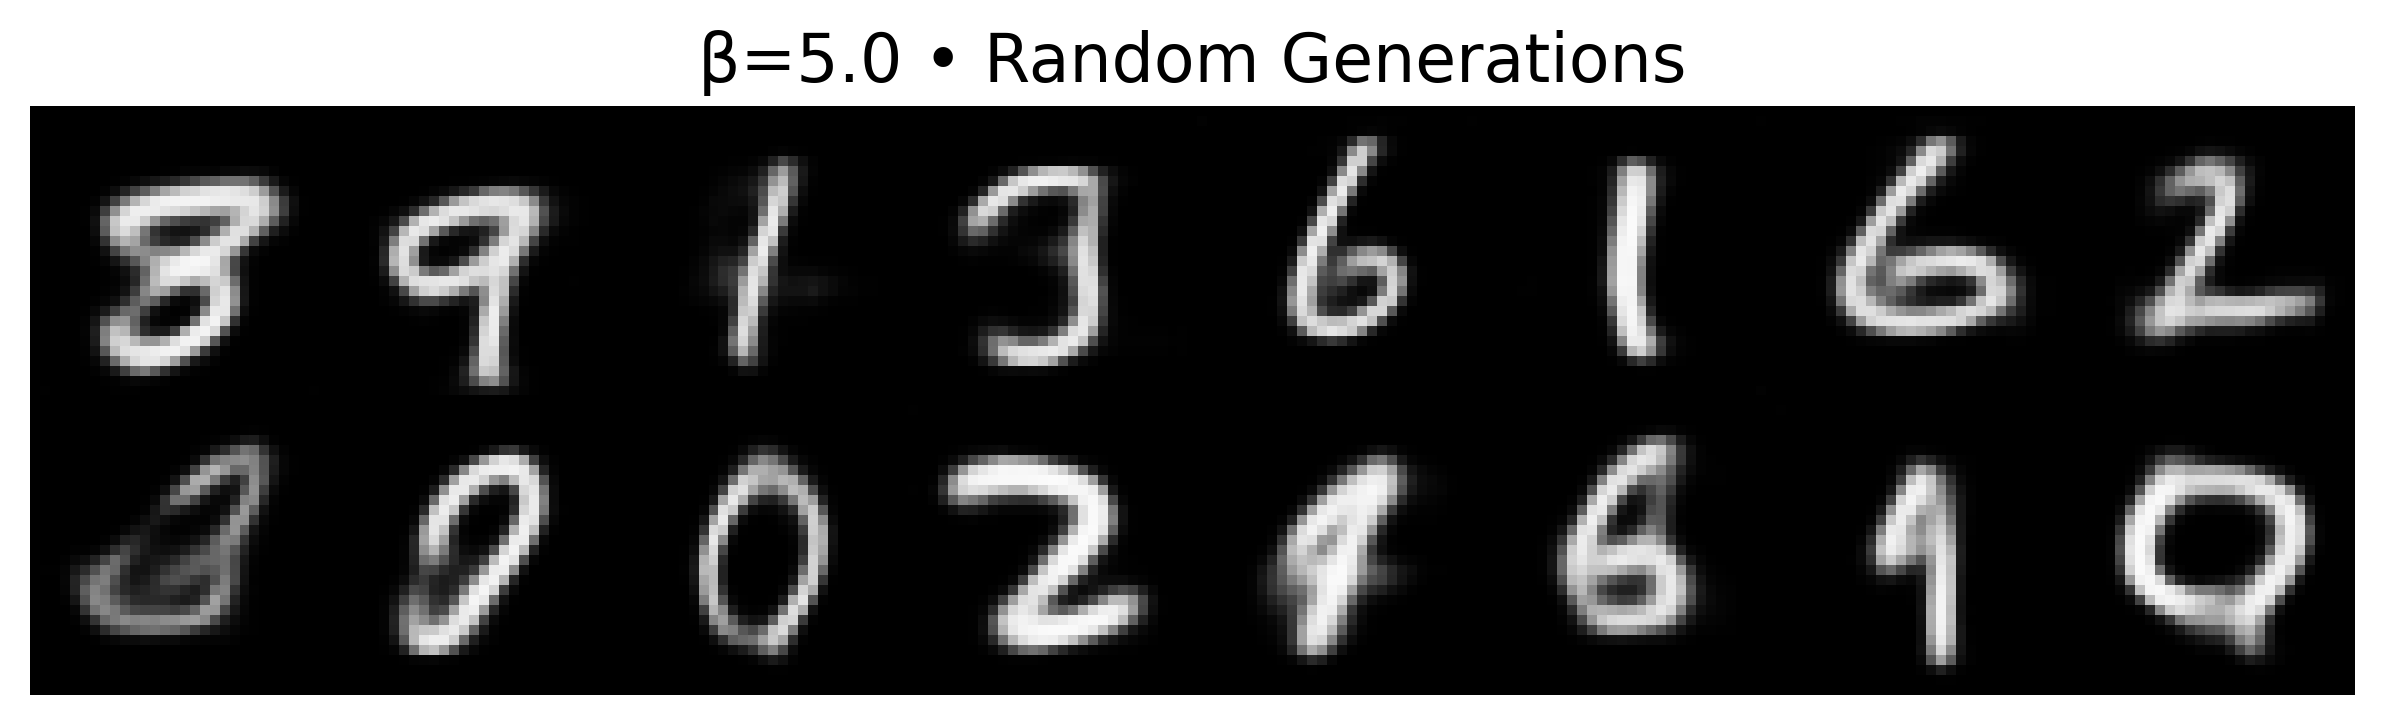

Experiment summaries:
β=0.5: Recon=16.5292, KL=41.5967, Recon/KL=0.40
β=1.0: Recon=24.4601, KL=28.8363, Recon/KL=0.85
β=3.0: Recon=44.7836, KL=15.1563, Recon/KL=2.95
β=5.0: Recon=60.8821, KL=10.9066, Recon/KL=5.58


In [10]:
# Define the β values you would like to explore
latent_dim = 128  # ensure consistency with the base experiment
beta_values = [0.5, 1.0, 3.0, 5.0]

# Containers for results recorded during the experiments
experiment_histories = {}
experiment_summaries = {}

# Prepare a test loader (shared across experiments)
test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

for beta in beta_values:
    print("" + "=" * 60)
    print(f"β-VAE Experiment (β={beta})")
    print("=" * 60)

    vae = ConvVAE(latent_dim=latent_dim, img_channels=1)
    vae, history = train_conv_vae(vae, train_loader, epochs=40, device=device, beta=beta, lr=1e-3)

    experiment_histories[beta] = history

    final_recon = history['recon'][-1]
    final_kld = history['kld'][-1]
    ratio = final_recon / (final_kld + 1e-8)

    print(f"Final Reconstruction Loss: {final_recon:.4f}")
    print(f"Final KL Divergence:      {final_kld:.4f}")
    print(f"Recon/KL Ratio:           {ratio:.2f}")

    vae.eval()
    with torch.no_grad():
        batch, _ = next(iter(test_loader))
        batch = batch.to(device)
        recon_batch, _, _ = vae(batch)

        plot_results(batch[:16], nrow=8, title=f'β={beta} • Original Samples')
        plot_results(recon_batch[:16], nrow=8, title=f'β={beta} • Reconstructions')

        z = torch.randn(32, latent_dim).to(device)
        generated = vae.decode(z)
        plot_results(generated[:16], nrow=8, title=f'β={beta} • Random Generations')

    experiment_summaries[beta] = {
        'final_recon': final_recon,
        'final_kld': final_kld,
        'ratio': ratio,
    }

print("Experiment summaries:")
for beta, summary in experiment_summaries.items():
    print(f"β={beta}: Recon={summary['final_recon']:.4f}, KL={summary['final_kld']:.4f}, Recon/KL={summary['ratio']:.2f}")

# β-VAE Experiment Summary (MNIST)


## Qualitative comparison across β settings
| β value | Reconstruction loss (relative) | KL divergence (relative) | Reconstruction quality | Generation quality |
|:------:|:------------------------------:|:------------------------:|:-----------------------|:-------------------|
| 0.5    | lowest                         | lowest                   | Sharp digits with high fidelity | Samples resemble training data closely but offer limited variation |
| 1.0    | low                            | moderate                 | Slightly blurrier yet still faithful digits | Improved diversity with realistic strokes |
| 3.0    | medium                         | higher                   | Noticeable blurring and occasional digit ambiguity | Broader latent usage leading to more varied but less crisp samples |
| 5.0    | highest                        | highest                  | Reconstructions lose fine details and may misclassify digits | Highly diverse generations, yet realism drops because samples become washed out |

The "relative" columns are ranked comparisons: higher β monotonically increases the contribution of the KL term, forcing encoder posteriors to remain close to the unit Gaussian. This inflates the measured KL divergence while preventing the model from allocating capacity to precise reconstructions, so the reconstruction loss grows with β.

## Effect on latent representations
Increasing β strengthens the pressure for each latent dimension to match the prior, promoting factorised posteriors. When β ≈ 1 (the conventional VAE), the model balances reconstruction fidelity and latent regularisation, producing latent codes that capture a mixture of shared and disentangled factors. As β is raised (3–5), the KL penalty dominates: encodings become more isotropic and independent, which encourages disentanglement and yields a latent space where traversals manipulate interpretable attributes (stroke thickness, slant, etc.). However, the stronger regularisation also restricts the amount of information each latent dimension can carry, so the decoder receives a less detailed signal and reconstructions appear blurrier.

Conversely, lowering β below 1 relaxes the information bottleneck. The encoder can devote more capacity to per-sample details, restoring sharp reconstructions but collapsing the latent space around training samples, which harms the model's ability to generate diverse digits.

## Takeaways
- β provides a knob between reconstruction fidelity and latent factorisation.
- Larger β values promote disentanglement by encouraging isotropic posteriors, but the resulting information bottleneck makes reconstructions less crisp.
- Moderate β (around 1) offers a compromise between faithful reconstructions and useful, moderately disentangled latent dimensions.